# 인공지능 3주차 김상우

In [2]:
class SGD:
    def __init__(self, lr = 0.01):
        self.lr = lr
        
    def update(self, params, grads):
        for key in params.key():
            params[key] = params[key] - self.lr * grads[key]

In [3]:
import numpy as np

class Momentum:
    def __init__(self, lr = 0.01, momentum = 0.9):
        self.lr = lr
        self.momentum = momentum
        self.v = None
    
    # param: 학습으로 수정할 매개변수
    # grads: 각 매개변수에 대한 손실함수의 기울기
    def update(self, params, grads): # 딕셔너리 형태로 전달
        if self.v is None:
            self.v = {} # 속도를 저장할 딕셔너리 생성
            for key, val in params.items():
                self.v[key] = np.zeros_like(val)
                
        for key in params.keys():
            self.v[key] = self.momentum*self.v[key] - self.lr*grads[key]
            params[key] += self.v[key]

In [4]:
class AdaGrad:
    def __init__(self, lr = 0.01):
        self.lr = lr
        self.h = None
        
    def update(self, params, grads):
        if self.h is None:
            self.h = {}
            for key, val in params.items():
                self.h[key] = np.zeros_like(val)
                
        for key in params.keys():
            self.h[key] += grads[key] * grads[key] # 첫번째 식
            params[key] -= self.lr * grads[key] / (np.sqrt(self.h[key]) + 1e-7)

### -기울기 감소 파악

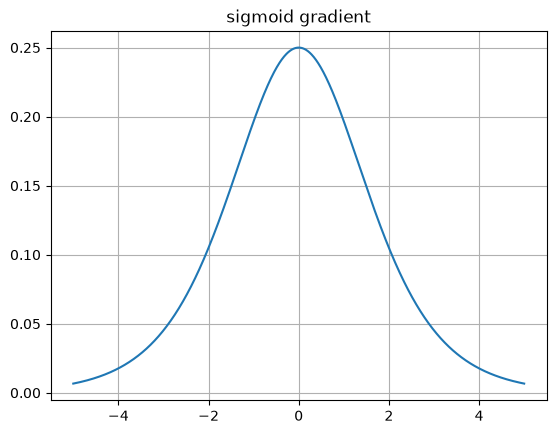

In [5]:
# 시그모이드에서 기울기 감소를 파악해보자 
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# 수치 미분 적용
def numerical_gradient(f, x):
    h = 1e-4
    grad = np.zeros_like(x)
    
    for idx in range(x.size):
        tmp_val = x[idx]
        x[idx] = tmp_val + h
        fxh1 = f(x)[idx]
        
        x[idx] = tmp_val - h
        fxh2 = f(x)[idx]
        
        grad[idx] = (fxh1 - fxh2) / (2*h)
        x[idx] = tmp_val
        
    return grad


x = np.linspace(-5, 5, 1000)
y = sigmoid(x)
ddx = numerical_gradient(sigmoid, x)

fig, ax = plt.subplots()
ax.plot(x, ddx, label = 'gradient')
ax.set_title('sigmoid gradient')
ax.grid()


위 그래프에서 보면 알 수 있듯이, 시그모이드 함수의 최대 기울기는 0.25정도이다. x가 0에서 멀어질수록 시그모이드 출력은 0 혹은 1에 가까워진다. 그러면 역전파를 구할 때 작은 기울기 값이 계속 곱해져, 입력값 쪽에 도달했을 때 기울기를 거의 전달하지 못한다.->기울기 소실

### Xavier

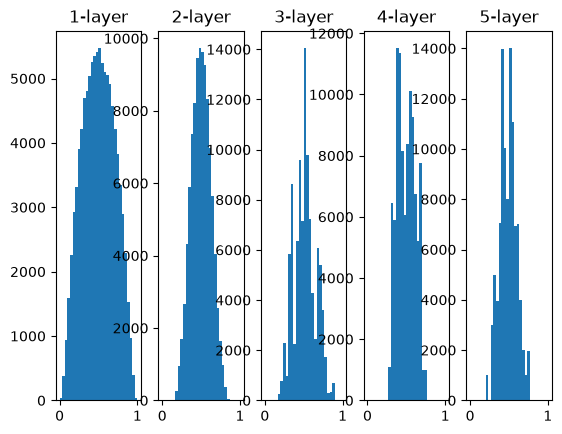

In [6]:
# Xavier. 교재 참고

import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

x = np.random.randn(1000,100)
node_num = 100
hidden_layer_size = 5
activations = {}

for i in range(hidden_layer_size):
    if i != 0:
        x = activations[i-1] # 이전 단계 계층
        
    w = np.random.randn(node_num, node_num) / np.sqrt(node_num)
    a = x @ w
    z = sigmoid(a)
    activations[i] = z
    
for i, a in activations.items():
    plt.subplot(1, len(activations), i+1)
    plt.title(str(i+1) + "-layer")
    plt.hist(a.flatten(), 30, range=(0,1))
    
plt.show()

## 노드 개수의 상관없은 신경망 구현

In [7]:
# 코드 구현 전 필요 한 변수, 함수 정리

# 1. 입력층 노드의 개수를 입력 받아야함
# 2. 각 히든레이어의 노드 수를 입력 받아야함.
# 3. 출력층 크기를 입력 받아야함
# 4. 어떤 활성화 함수를 사용할 것인지 입력 받아야함
# 5. 학습률 갱신 방법을 설정해야 함
# 6. 가중치의 초깃값 지정 방식을 생각해봐야함( ex. ReLU -> He, sigmoid -> Xavier)
# 7. 오차를 어떻게 구할 것인지도 생각해봐야함

# 8. 순전파 구현
# 9. 역전파 구현

In [8]:
import numpy as np
import time

# 활성화 함수
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def ReLU(x):
    return np.maximum(0, x)

def sigmoid_grad(output):

    return output * (1 - output)

def ReLU_grad(output):
    return (output >0).astype(float)

# 가중치 초기화
def He(input_size, output_size):
    return np.random.randn(input_size, output_size) * np.sqrt(2/input_size)

def Xavier(input_size, output_size):
    return ( np.random.randn(input_size, output_size) / np.sqrt(input_size))


# 신경망
class neuralNetwork:

    # =================================초기화====================================================
    def __init__(self ,layer_size, activation=sigmoid, learning_rate=0.1, seed=42):


    # 신경망 구조
        self.layer_size = list(layer_size)

        self.input_size = self.layer_size[0]

        self.hidden_size = self.layer_size[1:-1]
        self.output_size = self.layer_size[-1]

        # 함수 설정
        self.activation = activation
        
        if activation is sigmoid:
            self.activation_grad = sigmoid_grad
            self.weight_method = Xavier
        elif activation is ReLU:
            self.activation_grad = ReLU_grad
            self.weight_method = He
        else:
            print("Change activation function")

        self.learning_rate = learning_rate

        # 가중치, 기울기 딕셔너리 생성
        self.params = {}
        self.grads = {}

        # 순전파 값 저장 리스트 생성
        self.A_values = []
        self.Z_values = []

        self.output_value = None # 최종 출력 값
        self.L = None # 학습률 설정

        # 가중치와 편향 생성

        for i in range(1, len(self.layer_size)):
            input_node_num = self.layer_size[i - 1]
            output_node_num = self.layer_size[i]

            # 가중치
            self.params[f"W{i}"] = self.weight_method(input_node_num, output_node_num)

            # 편향
            self.params[f"b{i}"] = np.zeros((1, output_node_num))
            

    # ============================== 순전파 ===================================================================
    def forward(self, input_value):

        A = np.asarray(input_value, dtype=np.float64)

        if A.ndim == 1: # 데이터 하나가 들어온 경우 2차원으로 변경
            A = A.reshape(1, -1)

        # 초기화
        self.A_values = [A] # A_value: 활성화 함수 출력값 저장
        self.Z_values = [] # Z_value: 활성화 전 값 저장


        # 순전파 계산
        for i in range(1, len(self.layer_size)):

            W = self.params[f"W{i}"]
            b = self.params[f"b{i}"]

            Z = A @ W + b
            A = self.activation(Z)

            # 역전파 계산위해 저장
            self.Z_values.append(Z)
            self.A_values.append(A)

        self.output_value = A

        return A

    # ====================================역전파==========================================
    def backward(self, y_true):

        y_true = np.asarray(y_true, dtype=np.float64)

        y = self.output_value

        # y_true shape 정리(오류 원인을 파악하지 못해 AI의 도움을 받은 부분) ##############
        if y_true.ndim == 1:
            if (self.output_size == 1 and y_true.size == y.shape[0]):
                y_true = y_true.reshape(-1, 1)
            else: 
                y_true = y_true.reshape(1, -1)
        ###########################################        
        

        if y_true.shape != y.shape:
            print("Check y_ture shape")

        batch_size = y_true.shape[0]

        self.grads = {} # 이전 기울기 초기화

        # 1. 손실 계산
        self.L = 0.5 * np.mean(np.sum((y - y_true) ** 2,axis=1))

        # 2. 출력층 delta 계산
        dL_dy = (y - y_true) / batch_size
        dy_dZ = self.activation_grad(y)
        delta = dL_dy * dy_dZ

        # 3. 역전파
        for layer in range(len(self.layer_size)-1,0,-1):
            A_previous = self.A_values[layer - 1]

            W = self.params[f"W{layer}"]

            # 가중치 기울기
            self.grads[f"W{layer}"] = (A_previous.T @ delta)

            # 편향 기울기
            self.grads[f"b{layer}"] = np.sum(delta,axis=0,keepdims=True)

            if layer > 1:
                # 이전 층 출력 기울기
                dA_previous = delta @ W.T

                # 이전 층의 활성화 함수 출력
                A_previous_output = self.A_values[layer - 1]

                # 이전 층 활성화 함수 미분
                activation_gradient = (self.activation_grad(A_previous_output))

                # 이전 층 delta
                delta = (dA_previous* activation_gradient)

        return self.grads



    # ============================가중치 업데이트=================================
    def update(self):

        layer_count = len(self.layer_size) - 1

        for layer in range(1, layer_count + 1):

            self.params[f"W{layer}"] -= (self.learning_rate* self.grads[f"W{layer}"])

            self.params[f"b{layer}"] -= (self.learning_rate* self.grads[f"b{layer}"])

    # 학습
    def train_step(self, X, y_true):

        self.forward(X)
        self.backward(y_true)
        self.update()

        return self.L

    # 반복 학습
    def fit(self,X,y_true,epochs=100):
        loss_record = []
        for epoch in range(1, epochs + 1):

            loss = self.train_step(X,y_true)
            loss_record.append(loss)

        return loss_record
    
    def fit2(self, X, y_true, epochs=30000):
        X = np.asarray(X, dtype=np.float64)
        y_true = np.asarray(y_true, dtype=np.float64)
        data_size = X.shape[0]
        loss_record = []
        for epoch in range(epochs):
            epoch_loss = 0.0
            # 데이터 1개씩 순서대로 학습
            for sample in range(data_size):
                loss = self.train_step(
                    X[sample],
                    y_true[sample]
                )
                epoch_loss += loss
            epoch_loss /= data_size
            loss_record.append(epoch_loss)
        return loss_record

    # 예측
    def predict(self, X):

        return self.forward(X)

    # 신경망 정보 확인
    def info(self):

        print("Neural Network info")
        print("-" * 20)

        print(f"input Layer: {self.input_size}")


        for i in range(1, len(self.layer_size)):

            node_num = self.layer_size[i]

            if i == len(self.layer_size) -1:
                layer_name = "output Layer"
            else:
                layer_name = f"hidden Layer {i}"

            print(f"{layer_name}: {node_num}")

            print(f"  W{i}.shape = "f"{self.params[f'W{i}'].shape}")

            print(f"  b{i}.shape = "f"{self.params[f'b{i}'].shape}")

In [9]:
# TEST

# 1의 개수가 짝수이면 [1, 0]
# 1의 개수가 홀수이면 [0, 1]

X = np.array([
    [0, 0, 0],
    [0, 0, 1],
    [0, 1, 0],
    [0, 1, 1],
    [1, 0, 0],
    [1, 0, 1],
    [1, 1, 0],
    [1, 1, 1]
], dtype=np.float64)

y_true = np.array([
    [1, 0],
    [0, 1],
    [0, 1],
    [1, 0],
    [0, 1],
    [1, 0],
    [1, 0],
    [0, 1]
], dtype=np.float64)

model = neuralNetwork(layer_size=[3, 4, 2, 2],activation=sigmoid,learning_rate=0.5,seed=42)
model.info()

start_time = time.perf_counter()
loss_record = model.fit(X,y_true,epochs=300000)
y_pred = model.predict(X)

end_time = time.perf_counter()
elapsed_time = end_time - start_time

print(f"Python 학습 시간: {elapsed_time:.6f}초")
print("\n학습 결과")

for sample in range(len(X)):
    print(
        f"{X[sample, 0]:.0f} "
        f"{X[sample, 1]:.0f} "
        f"{X[sample, 2]:.0f} "
        f"-> "
        f"{y_pred[sample, 0]:.6f} "
        f"{y_pred[sample, 1]:.6f}"
    )

Neural Network info
--------------------
input Layer: 3
hidden Layer 1: 4
  W1.shape = (3, 4)
  b1.shape = (1, 4)
hidden Layer 2: 2
  W2.shape = (4, 2)
  b2.shape = (1, 2)
output Layer: 2
  W3.shape = (2, 2)
  b3.shape = (1, 2)
Python 학습 시간: 20.871580초

학습 결과
0 0 0 -> 0.997654 0.002328
0 0 1 -> 0.001850 0.998169
0 1 0 -> 0.002746 0.997309
0 1 1 -> 0.997033 0.002948
1 0 0 -> 0.003269 0.996746
1 0 1 -> 0.997635 0.002316
1 1 0 -> 0.997903 0.002078
1 1 1 -> 0.002031 0.997986


In [10]:
# ReLU test: y = 2*x1 + 3*x2
np.random.seed(0)

X_relu = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1],
    [2, 1],
    [1, 2]
], dtype=np.float64)

y_relu = np.array([
    [0],
    [3],
    [2],
    [5],
    [7],
    [8]
], dtype=np.float64)

relu_model = neuralNetwork(layer_size=[2, 6, 1],activation=ReLU,learning_rate=0.01)

loss_history = relu_model.fit(X_relu, y_relu, epochs=2000)
prediction = relu_model.predict(X_relu)

print("first loss:", loss_history[0])
print("last loss :", loss_history[-1])

print("\nexpected / prediction")
print(np.hstack((y_relu, prediction)))

first loss: 2.1145035103159024
last loss : 0.0010960001507904465

expected / prediction
[[0.         0.02891512]
 [3.         2.94456054]
 [2.         2.04961246]
 [5.         4.96076716]
 [7.         6.96480621]
 [8.         8.06320281]]
